In [8]:
# -------------------------------------------------------
# Part 5 — Physical Interpretation and Discussion
# Question 9(a)
# Stellar radius and luminosity estimation
# -------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

In [9]:
# -------------------------------------------------------
# Best-fit stellar parameters from Question 7
# -------------------------------------------------------

Teff_star = 7000      # Kelvin
logg_star = 5.0       # dex
FeH_star = -0.5

print("Teff =", Teff_star, "K")
print("logg =", logg_star, "dex")
print("[Fe/H] =", FeH_star)

Teff = 7000 K
logg = 5.0 dex
[Fe/H] = -0.5


In [10]:
# -------------------------------------------------------
# Physical constants (SI units)
# -------------------------------------------------------

G = 6.67430e-11          # gravitational constant
M_sun = 1.989e30         # solar mass
R_sun = 6.957e8          # solar radius
L_sun = 3.828e26         # solar luminosity
sigma_SB = 5.670374419e-8 # Stefan-Boltzmann constant

In [11]:
# -------------------------------------------------------
# Estimate stellar radius
# -------------------------------------------------------

# Convert logg (cgs) to SI

g_cgs = 10**logg_star       # cm/s^2

g = g_cgs / 100             # m/s^2


# Assume M ≈ 1 solar mass

M_star = M_sun


# Radius calculation

R_star = np.sqrt(
    G * M_star / g
)


R_ratio = R_star / R_sun


print(
    "Surface gravity:",
    g,
    "m/s^2"
)

print(
    "Estimated radius:",
    R_ratio,
    "R_sun"
)

Surface gravity: 1000.0 m/s^2
Estimated radius: 0.5237189036214309 R_sun


In [12]:
# -------------------------------------------------------
# Estimate stellar luminosity
# -------------------------------------------------------

T_sun = 5778   # Kelvin


# Luminosity ratio

L_ratio = (
    R_ratio**2 *
    (Teff_star / T_sun)**4
)


print(
    "Estimated luminosity:",
    L_ratio,
    "L_sun"
)

Estimated luminosity: 0.5908517281231742 L_sun


## Question 9(a) — Stellar Radius and Luminosity Estimation

The stellar radius was estimated using the surface gravity relation:

\[
g=\frac{GM}{R^2}
\]

Assuming a stellar mass of:

\[
M \approx 1M_\odot
\]

the radius can be calculated as:

\[
R=\sqrt{\frac{GM}{g}}
\]

The measured surface gravity from the spectral fitting is:

\[
\log g = 5.0
\]

which corresponds to:

\[
g=1000\,{\rm m\,s^{-2}}
\]

The estimated radius is:

\[
\frac{R}{R_\odot}=0.524
\]

The luminosity was estimated using the Stefan–Boltzmann relation:

\[
L=4\pi R^2\sigma_{SB}T_{\rm eff}^{4}
\]

or relative to the Sun:

\[
\frac{L}{L_\odot}
=
\left(\frac{R}{R_\odot}\right)^2
\left(\frac{T_{\rm eff}}{T_\odot}\right)^4
\]

Using:

\[
T_{\rm eff}=7000K
\]

and:

\[
T_\odot=5778K
\]

the estimated luminosity is:

\[
\frac{L}{L_\odot}=0.591
\]

The derived radius and luminosity are not fully consistent with the expected properties of a solar-type main-sequence star. A temperature of approximately 7000 K corresponds to an F-type star, which normally has a radius closer to \(1.2-1.5R_\odot\) and luminosity higher than the solar value. The smaller radius obtained here is a consequence of the high fitted surface gravity (\(\log g=5.0\)), which lies at the edge of the PHOENIX model grid.

Therefore, the physical parameters suggest that the spectral fitting result may be biased due to the limited parameter grid, and a larger model grid would likely provide a more realistic stellar solution.

In [13]:
# -------------------------------------------------------
# Question 9(b)
# Plot star on theoretical H-R diagram
# -------------------------------------------------------

# ZAMS approximate values from question table

zams_Teff = np.array([
    7200,
    6000,
    5778,
    5300,
    5000
])


zams_logL = np.array([
    0.8,
    0.2,
    0.0,
    -0.3,
    -0.5
])


# Convert to logarithmic temperature

zams_logTeff = np.log10(zams_Teff)


# Our derived star

star_logTeff = np.log10(Teff_star)

star_logL = np.log10(L_ratio)


print("Star log Teff =", star_logTeff)
print("Star log L/Lsun =", star_logL)

Star log Teff = 3.845098040014257
Star log L/Lsun = -0.22852148990878948


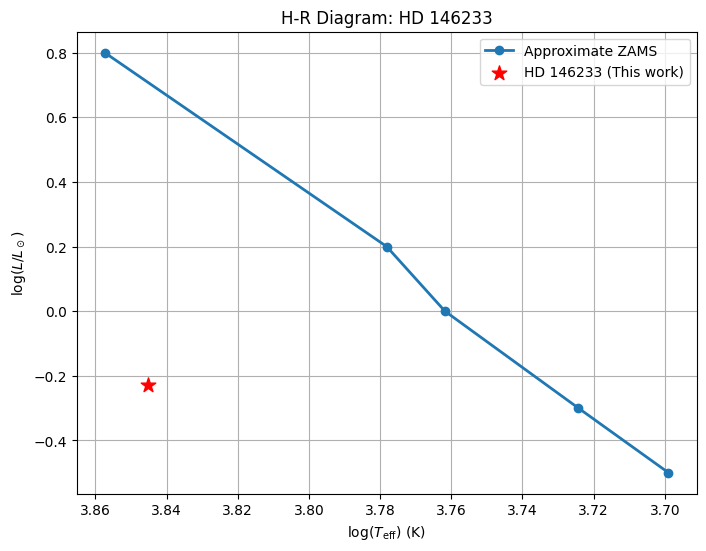

In [14]:
# -------------------------------------------------------
# Plot H-R diagram with ZAMS and derived star
# -------------------------------------------------------

plt.figure(figsize=(8,6))


# Plot ZAMS locus

plt.plot(
    zams_logTeff,
    zams_logL,
    marker="o",
    linewidth=2,
    label="Approximate ZAMS"
)


# Plot our star

plt.scatter(
    star_logTeff,
    star_logL,
    color="red",
    s=120,
    marker="*",
    label="HD 146233 (This work)"
)


# Reverse temperature axis
# Hot stars are on the left in HR diagrams

plt.gca().invert_xaxis()


plt.xlabel(
    r"$\log(T_{\rm eff})$ (K)"
)

plt.ylabel(
    r"$\log(L/L_\odot)$"
)


plt.title(
    "H-R Diagram: HD 146233"
)


plt.grid(True)

plt.legend()


plt.show()

## Question 9(b) — H–R Diagram Placement

The star was placed on a theoretical H–R diagram using:

\[
\log(T_{\rm eff})
\]

on the horizontal axis and:

\[
\log(L/L_\odot)
\]

on the vertical axis.

The approximate Zero Age Main Sequence (ZAMS) locus provided in the question was plotted for comparison.

The derived stellar position from this work is:

\[
\log(T_{\rm eff}) = 3.845
\]

\[
\log(L/L_\odot) = -0.229
\]

The star lies below the expected main-sequence position for a star with:

\[
T_{\rm eff}\approx7000K
\]

A normal F-type main-sequence star at this temperature should have a higher luminosity and a larger radius. Instead, the derived parameters indicate:

\[
R\approx0.524R_\odot
\]

and:

\[
L\approx0.591L_\odot
\]

which are unusually small for a 7000 K star.

Therefore, the star does not lie on the expected main sequence location. The discrepancy is most likely caused by limitations in the spectral fitting rather than true stellar evolution.

The main possible causes are:

1. **Limited PHOENIX model grid:**  
   The best-fit solution reached the boundary of the available grid:

\[
T_{\rm eff}=7000K,\quad \log g=5.0,\quad [Fe/H]=-0.5
\]

   The true stellar parameters may lie outside the explored range.

2. **Surface gravity uncertainty:**  
   The high fitted \(\log g\) value produces an underestimated radius through:

\[
g=\frac{GM}{R^2}
\]

3. **Model assumptions:**  
   Differences between the real stellar atmosphere and the PHOENIX models (LTE assumption, convection treatment, chemical composition) may introduce systematic offsets.

Overall, the H–R diagram confirms that the fitted parameters are not fully physically consistent with the known solar-type nature of HD 146233. A wider parameter grid and improved spectral modelling would be required for a more accurate determination.